In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

In [2]:
# 指定亂數種子
seed = 7
np.random.seed(seed)

In [3]:
# 載入 MNIST 資料集, 如果是第一次載入會自行下載資料集
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [4]:
X_test_bk = X_test.copy()   # 備份 X_test 資料集 (為了最後推論模型用)
Y_test_bk = Y_test.copy()   # 備份 Y_test 資料集 

## 圖檔前處理

In [5]:
# 將圖片轉換成 4D 張量 (與MLP所使用的不同)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype("float32")
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype("float32")
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)

X_train Shape:  (60000, 28, 28, 1)
X_test Shape:  (10000, 28, 28, 1)


In [6]:
# 因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_train = X_train / 255
X_test = X_test / 255

In [7]:
# One-hot編碼
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)

## 訓練CNN模型

In [8]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), padding="same", input_shape=X_train.shape[1:], activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(512, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))
model.summary()   # 顯示模型摘要資訊

/Users/lin/Downloads/deep-learning-basics/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,630,090 (6.22 MB)

 Trainable params: 1,630,090 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 編譯模型
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [10]:
# 訓練模型
history = model.fit(X_train, Y_train, validation_split=0.2, epochs=10, batch_size=128, verbose=2)

Epoch 1/10
375/375 - 29s - 76ms/step - accuracy: 0.9158 - loss: 0.2677 - val_accuracy: 0.9789 - val_loss: 0.0700
Epoch 2/10
375/375 - 23s - 62ms/step - accuracy: 0.9742 - loss: 0.0856 - val_accuracy: 0.9857 - val_loss: 0.0484
Epoch 3/10
375/375 - 24s - 63ms/step - accuracy: 0.9797 - loss: 0.0656 - val_accuracy: 0.9885 - val_loss: 0.0398
Epoch 4/10
375/375 - 28s - 75ms/step - accuracy: 0.9834 - loss: 0.0524 - val_accuracy: 0.9876 - val_loss: 0.0398
Epoch 5/10
375/375 - 29s - 77ms/step - accuracy: 0.9854 - loss: 0.0459 - val_accuracy: 0.9907 - val_loss: 0.0324
Epoch 6/10
375/375 - 26s - 70ms/step - accuracy: 0.9870 - loss: 0.0392 - val_accuracy: 0.9907 - val_loss: 0.0332
Epoch 7/10
375/375 - 32s - 85ms/step - accuracy: 0.9886 - loss: 0.0347 - val_accuracy: 0.9905 - val_loss: 0.0361
Epoch 8/10
375/375 - 24s - 65ms/step - accuracy: 0.9889 - loss: 0.0329 - val_accuracy: 0.9911 - val_loss: 0.0326
Epoch 9/10
375/375 - 31s - 84ms/step - accuracy: 0.9903 - loss: 0.0290 - val_accuracy: 0.9907 - 

In [11]:
# 評估模型
print("\nTesting ...")
loss, accuracy = model.evaluate(X_train, Y_train, verbose=0)
print("訓練資料集的準確度 = {:.4f}".format(accuracy))
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print("測試資料集的準確度 = {:.4f}".format(accuracy))


Testing ...
訓練資料集的準確度 = 0.9962
測試資料集的準確度 = 0.9917


In [12]:
# 計算分類的預測值
print("\nPredicting ...")
Y_pred = model.predict(X_test)
Y_pred_classes=np.argmax(Y_pred,axis=1)

# 顯示混淆矩陣
tb = pd.crosstab(Y_test_bk.astype(int), Y_pred_classes.astype(int), rownames=["label"], colnames=["predict"])
print(tb)


Predicting ...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
predict    0     1     2    3    4    5    6     7    8     9
label                                                        
0        975     1     0    0    0    0    3     1    0     0
1          0  1133     1    0    1    0    0     0    0     0
2          1     4  1020    0    0    0    0     5    2     0
3          0     0     3  999    0    6    0     0    2     0
4          0     0     0    0  972    0    2     0    0     8
5          2     0     0    1    0  888    1     0    0     0
6          2     3     0    0    1    1  950     0    1     0
7          0     4     3    0    0    0    0  1016    1     4
8          3     1     1    1    0    0    0     0  962     6
9          0     0     0    0    2    3    0     2    0  1002


In [13]:
model.save("413570012_HW5.keras")

## 顯示圖表來分析模型的訓練過程

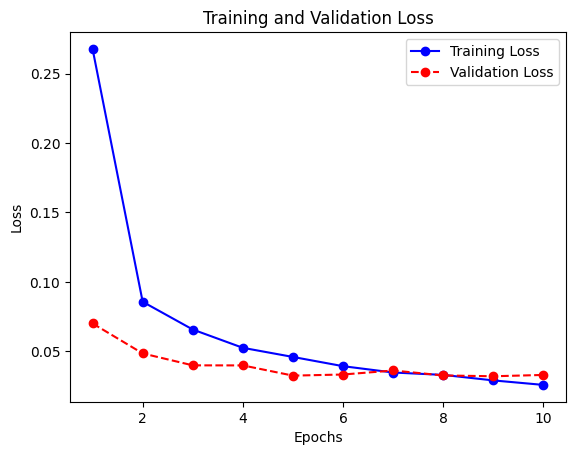

In [14]:
# 顯示訓練和驗證損失
loss = history.history["loss"]
epochs = range(1, len(loss)+1)
val_loss = history.history["val_loss"]
plt.plot(epochs, loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "ro--", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


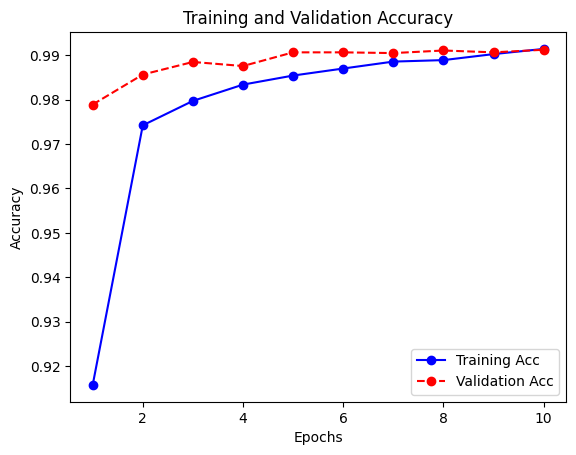

In [15]:
# 顯示訓練和驗證準確度
acc = history.history["accuracy"]
epochs = range(1, len(acc)+1)
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo-", label="Training Acc")
plt.plot(epochs, val_acc, "ro--", label="Validation Acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 模型推論，辨識照片中的數字為何

In [16]:
# 亂數選一個測試的數字圖片 
i = np.random.randint(0, len(X_test))
digit = X_test_bk[i].reshape(28, 28)
# 將圖片轉換成 4D 張量
X_test_digit = X_test_bk[i].reshape(1, 28, 28, 1).astype("float32")
# 因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_test_digit = X_test_digit / 255

In [17]:
# 建立Keras的Sequential模型
model_inference = Sequential()
model_inference = load_model("413570012_HW5.keras")
# 編譯模型
model_inference.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

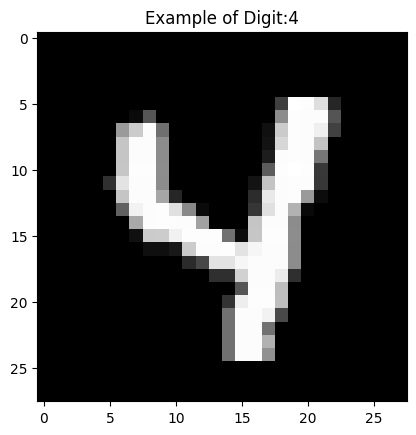

In [18]:
# 繪出圖表的預測結果
plt.figure()
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")

In [19]:
# 預測結果的機率
print("Predicting ...")
probs = model_inference.predict(X_test_digit, batch_size=1)
print(probs)

Predicting ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[[6.7945608e-15 8.5413338e-10 5.1720106e-14 3.5083890e-16 1.0000000e+00
  2.8749455e-12 7.2528348e-14 5.5574856e-10 1.6103032e-09 2.2277715e-09]]


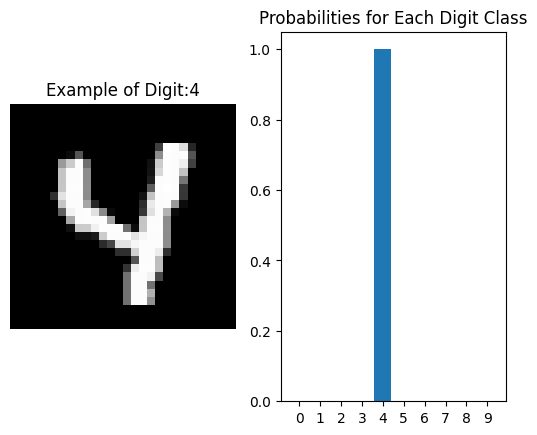

In [20]:
# 繪出圖表的預測結果
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Probabilities for Each Digit Class")
plt.bar(np.arange(10), probs.reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()

## 檢查辨識錯誤的數字圖檔

In [21]:
# 測試資料集的分類和機率的預測值
Y_pred_probs = model_inference.predict(X_test)     # 預測機率
Y_pred_classes= np.argmax(Y_pred_probs,axis=1)   # 轉成分類

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [22]:
# 建立分類錯誤的 DataFrame 物件
df = pd.DataFrame({"label":Y_test_bk, "predict":Y_pred_classes})
df = df[Y_test_bk!=Y_pred_classes]  # 篩選出分類錯誤的資料
print(df.head()) # 看前五筆分類錯誤

     label  predict
158      3        2
321      2        7
445      6        0
449      3        5
659      2        1


Index:  1226


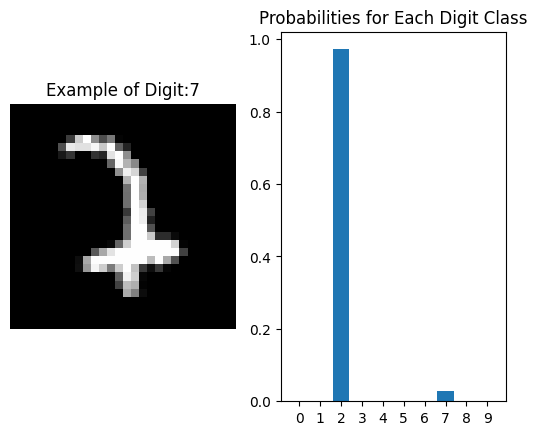

In [23]:
# 隨機選 1 個錯誤分類的數字索引
i = df.sample(n=1).index.values.astype(int)[0]
print("Index: ", i)
digit = X_test_bk[i].reshape(28, 28) 
# 繪出圖表的預測結果
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Probabilities for Each Digit Class")
plt.bar(np.arange(10), Y_pred_probs[i].reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()

In [24]:
# 預測錯誤的筆數
len(df)

83

In [25]:
# 作業計算公式
base = 80
score_upperB = 100
score_lowerB = 80
score = 100-((score_upperB-score_lowerB)*(len(df)/base))

print(score)

79.25
